In [1]:
from src.dataset.builder import build_training_dataset
from src.models.split import time_series_split
from src.visualization.eda import (
    plot_class_balance,
    plot_feature_correlations,
    plot_feature_distributions,
)

Matplotlib is building the font cache; this may take a moment.


In [2]:
dataset = build_training_dataset()
train, test = time_series_split(dataset)

print("Dataset shape:", dataset.shape)
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nDate range:")
print(dataset["timestamp"].min())
print(dataset["timestamp"].max())

Dataset shape: (948, 12)
Train shape: (758, 12)
Test shape: (190, 12)

Date range:
2022-03-15 04:00:00+00:00
2025-12-22 05:00:00+00:00


In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 948 entries, 0 to 947
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticker                 948 non-null    str    
 1   timestamp              948 non-null    str    
 2   return_1d              948 non-null    float64
 3   return_5d              948 non-null    float64
 4   sma_20                 948 non-null    float64
 5   sma_50                 948 non-null    float64
 6   ema_20                 948 non-null    float64
 7   volatility_20          948 non-null    float64
 8   volume_ratio_20        948 non-null    float64
 9   forward_return_5d      948 non-null    float64
 10  qqq_forward_return_5d  948 non-null    float64
 11  outperformed_qqq       948 non-null    int64  
dtypes: float64(9), int64(1), str(2)
memory usage: 89.0 KB


In [4]:
dataset.describe()

,return_1d,return_5d,sma_20,sma_50,ema_20,volatility_20,volume_ratio_20,forward_return_5d,qqq_forward_return_5d,outperformed_qqq
count,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000
mean,0.000780,0.003714,191.262883,189.608341,191.290851,0.016606,0.999457,0.003583,0.003617,0.530591
std,0.017946,0.039652,35.566420,33.438581,35.368227,0.007341,0.372800,0.039480,0.030591,0.499327
min,-0.092456,-0.227474,130.944000,138.760600,132.383232,0.005960,0.412057,-0.227474,-0.119822,0.000000
25%,-0.007580,-0.019756,163.981875,160.708900,163.249024,0.011899,0.788210,-0.019651,-0.014169,0.000000
50%,0.001165,0.003734,187.050875,184.353200,186.227224,0.015372,0.916176,0.003734,0.006198,1.000000
75%,0.009611,0.028449,222.207500,220.163650,222.268753,0.019170,1.111670,0.028125,0.021640,1.000000
max,0.153288,0.172370,277.514000,270.031800,276.471364,0.051535,5.245379,0.172370,0.100779,1.000000


In [5]:
dataset["outperformed_qqq"].value_counts()

outperformed_qqq
1    503
0    445
Name: count, dtype: int64

In [6]:
dataset["outperformed_qqq"].value_counts(normalize=True)

outperformed_qqq
1    0.530591
0    0.469409
Name: proportion, dtype: float64

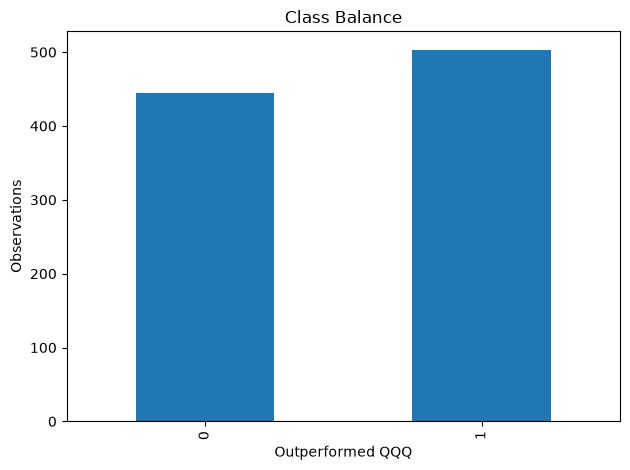

In [7]:
plot_class_balance(dataset)

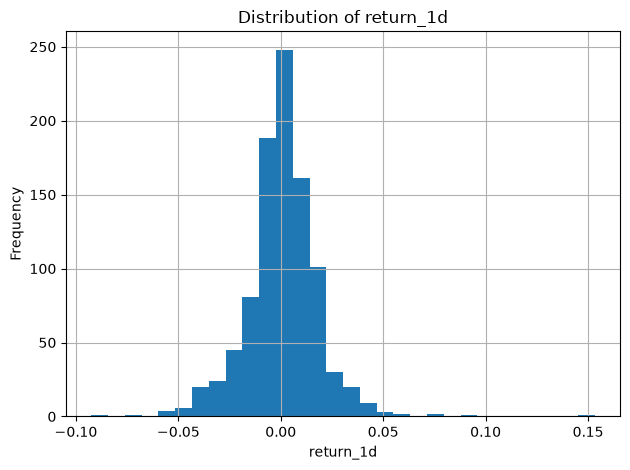

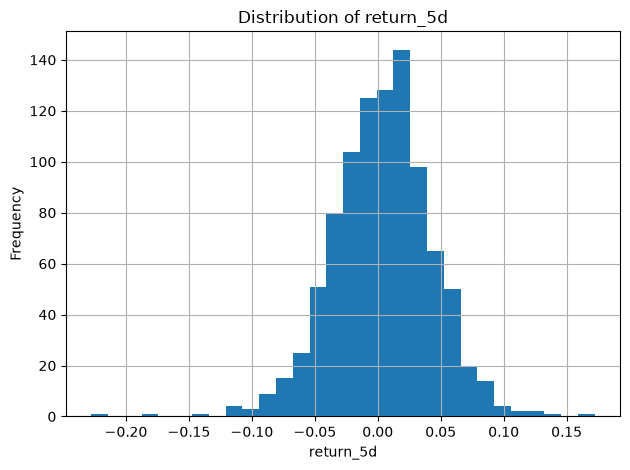

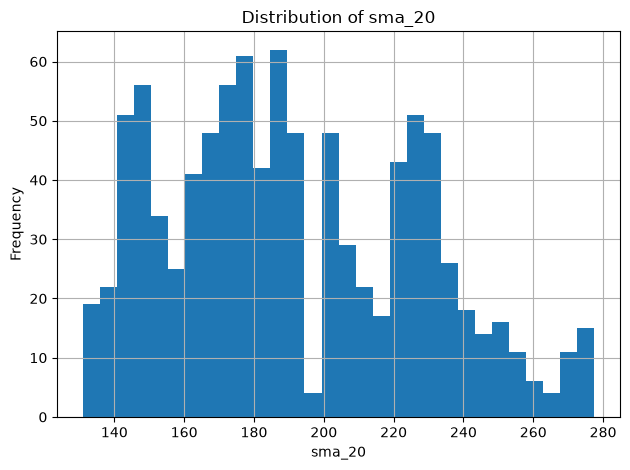

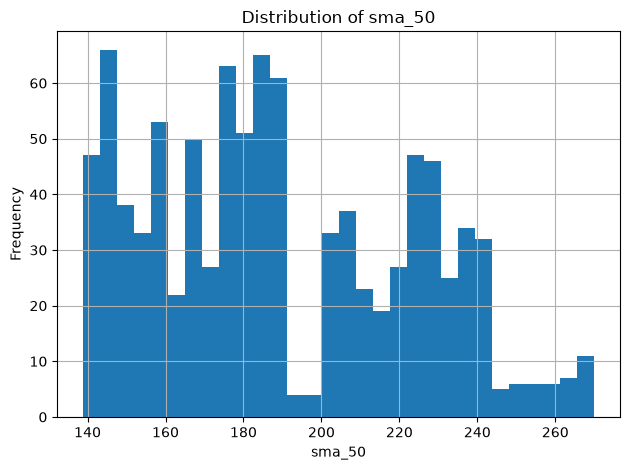

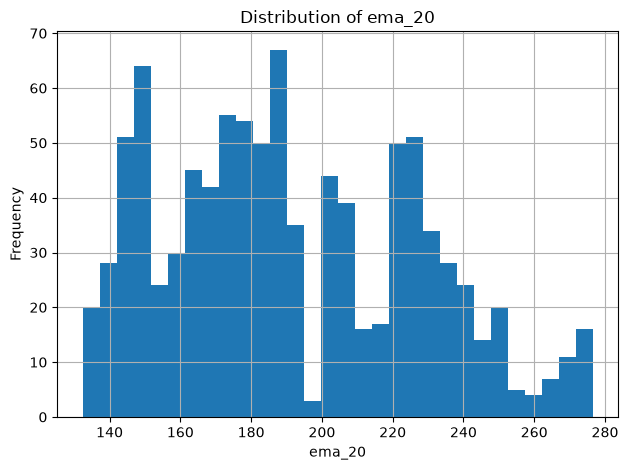

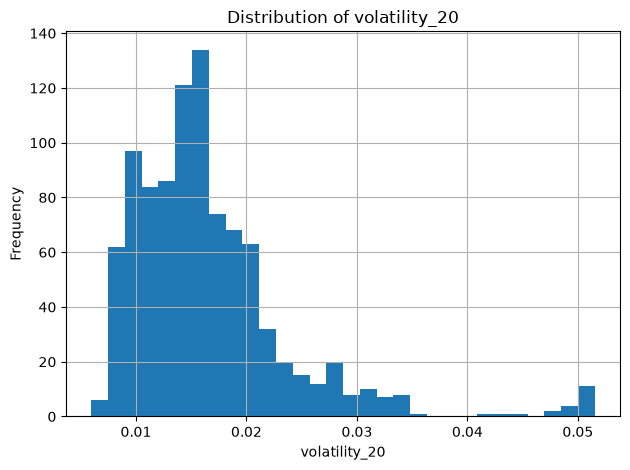

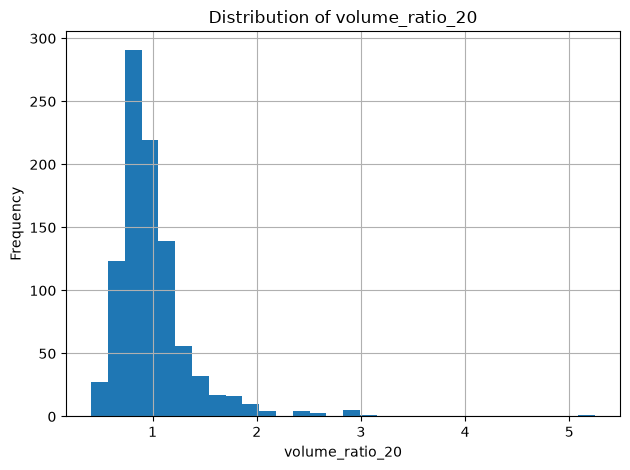

In [8]:
plot_feature_distributions(dataset)

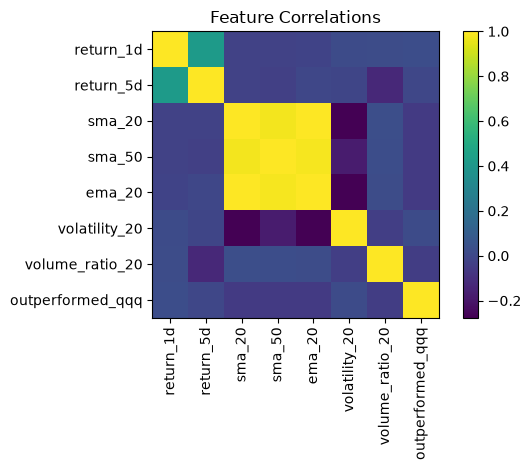

In [9]:
plot_feature_correlations(dataset)

In [10]:
correlations = dataset[
    [
        "return_1d",
        "return_5d",
        "sma_20",
        "sma_50",
        "ema_20",
        "volatility_20",
        "volume_ratio_20",
        "outperformed_qqq",
    ]
].corr()

correlations["outperformed_qqq"].sort_values(ascending=False)

outperformed_qqq    1.000000
return_1d           0.026018
volatility_20       0.015756
return_5d          -0.005708
volume_ratio_20    -0.045564
sma_50             -0.058145
sma_20             -0.060133
ema_20             -0.060723
Name: outperformed_qqq, dtype: float64

In [12]:
period_comparison = {
    "train_mean": train[feature_columns].mean(),
    "test_mean": test[feature_columns].mean(),
    "train_std": train[feature_columns].std(),
    "test_std": test[feature_columns].std(),
}

import pandas as pd

pd.DataFrame(period_comparison)

,train_mean,test_mean,train_std,test_std
return_1d,0.000634,0.001361,0.017015,0.021298
return_5d,0.002775,0.007459,0.037256,0.047969
sma_20,182.041884,228.049816,31.434140,26.060363
sma_50,180.715065,225.087833,29.899457,20.957876
ema_20,182.021949,228.268894,31.159465,25.687328
volatility_20,0.016068,0.018753,0.005780,0.011420
volume_ratio_20,0.998760,1.002238,0.360432,0.419556


In [13]:
print("Training label distribution:")
print(train["outperformed_qqq"].value_counts(normalize=True))

print("\nTesting label distribution:")
print(test["outperformed_qqq"].value_counts(normalize=True))

Training label distribution:
outperformed_qqq
1    0.542216
0    0.457784
Name: proportion, dtype: float64

Testing label distribution:
outperformed_qqq
0    0.515789
1    0.484211
Name: proportion, dtype: float64
